# Phân Tích Dữ Liệu Chất Lượng Không Khí (Air Quality)
Pipeline phân tích, xử lý, trực quan hoá dữ liệu và xây dựng mô hình dự đoán.
Yêu cầu: Đọc dữ liệu `raw.csv`, tiền xử lý, phân tích thống kê, trực quan hóa, kiểm định giả thuyết và tạo mô hình học máy.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
# Thiết lập style cho đồ thị
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Thu thập và Tiền xử lý dữ liệu

In [8]:
# Đọc dữ liệu từ file csv (Dữ liệu cách nhau bởi dấu chấm phẩy, dấu thập phân là phẩy)
data_path = r'../data/raw.csv'
print(f"Đang đọc dữ liệu từ: {data_path}")
df = pd.read_csv(data_path, sep=';', decimal=',')

# Xóa các cột trống (thường có tên 'Unnamed: ...' do có dấy ; dư ở cuối mỗi dòng)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Xóa các dòng trống hoàn toàn (thường ở cuối file)
df.dropna(how='all', inplace=True)

print("Kích thước dữ liệu ban đầu:", df.shape)
print("\nDữ liệu 5 dòng đầu:")
display(df.head())

# Xử lý giá trị bị khuyết: Trong Air Quality UCI dataset, missing value được ký hiệu là -200
print("\nSố lượng giá trị -200 (missing) trong mỗi cột:")
print((df == -200).sum())

# Thay thế -200 bằng NaN
df.replace(-200, np.nan, inplace=True)

# Kết hợp Date và Time thành cột Datetime kiểu chuẩn
if 'Date' in df.columns and 'Time' in df.columns:
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
    df.drop(['Date', 'Time'], axis=1, inplace=True)
    df.set_index('Datetime', inplace=True)

print("\nThông tin dữ liệu sau khi định dạng lại thời gian:")
df.info()

# Nội suy dữ liệu thiếu (Interpolation) cho dữ liệu chuỗi thời gian
df.interpolate(method='time', inplace=True)

# Điền các giá trị NaN ở đầu hoặc cuối bằng bfill và ffill
df.bfill(inplace=True)
df.ffill(inplace=True)

print("\nTổng số missing values sau khi tiền xử lý:", df.isnull().sum().sum())

Đang đọc dữ liệu từ: ../data/raw.csv
Kích thước dữ liệu ban đầu: (9357, 15)

Dữ liệu 5 dòng đầu:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888



Số lượng giá trị -200 (missing) trong mỗi cột:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

Thông tin dữ liệu sau khi định dạng lại thời gian:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        7718 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)      

## 2. Phân tích thống kê

In [9]:
# Thống kê mô tả (Mean, Standard Deviation, Min, Max)
desc_stats = df.describe().T
# Thêm cột Median (Trung vị)
desc_stats['median'] = df.median()

print("\n--- Bảng Thống Kê Mô Tả ---")
display(desc_stats[['mean', 'median', 'std', 'min', 'max']])

# Hàm phát hiện ngoại lai bằng phương pháp IQR (Interquartile Range)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

outliers_T = detect_outliers_iqr(df, 'T')
outliers_CO = detect_outliers_iqr(df, 'CO(GT)')

print(f"\nSố dòng chứa ngoại lai ở Nhiệt độ (T): {len(outliers_T)} dòng")
print(f"Số dòng chứa ngoại lai ở Nồng độ CO(GT): {len(outliers_CO)} dòng")


--- Bảng Thống Kê Mô Tả ---


,mean,median,std,min,max
CO(GT),2.130603,1.800000,1.431736,0.1000,11.900
PT08.S1(CO),1103.059741,1067.000000,218.196346,647.0000,2040.000
NMHC(GT),269.834349,275.000000,74.251999,7.0000,1189.000
C6H6(GT),10.179155,8.300000,7.503812,0.1000,63.700
PT08.S2(NMHC),942.142620,910.012987,267.866611,383.0000,2214.000
NOx(GT),241.922197,180.000000,204.315075,2.0000,1479.000
PT08.S3(NOx),832.758897,804.000000,255.709833,322.0000,2683.000
NO2(GT),109.632094,104.917526,46.462311,2.0000,340.000
PT08.S4(NO2),1453.298814,1460.000000,343.206131,551.0000,2775.000
PT08.S5(O3),1032.544298,970.000000,404.447613,221.0000,2523.000



Số dòng chứa ngoại lai ở Nhiệt độ (T): 3 dòng
Số dòng chứa ngoại lai ở Nồng độ CO(GT): 224 dòng


## 3. Trực quan hóa dữ liệu

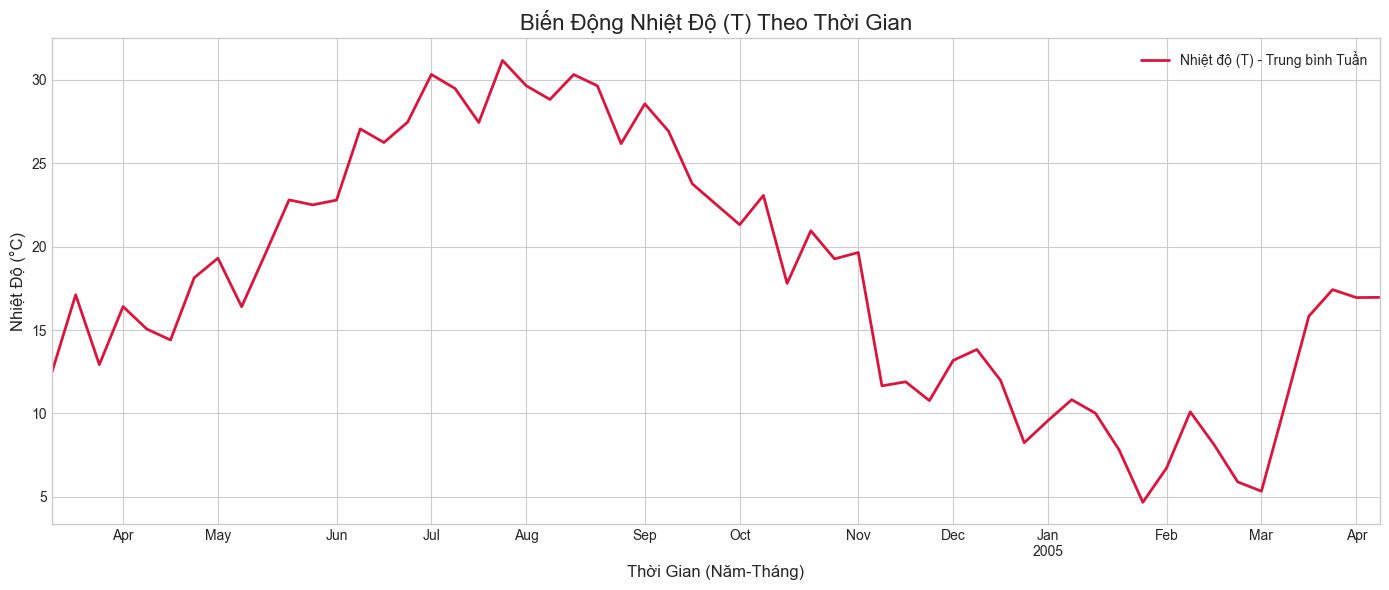

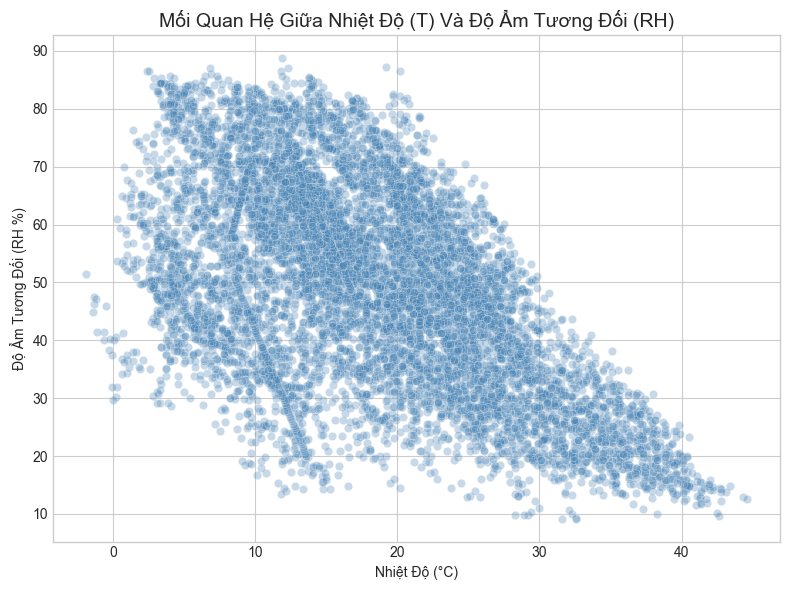

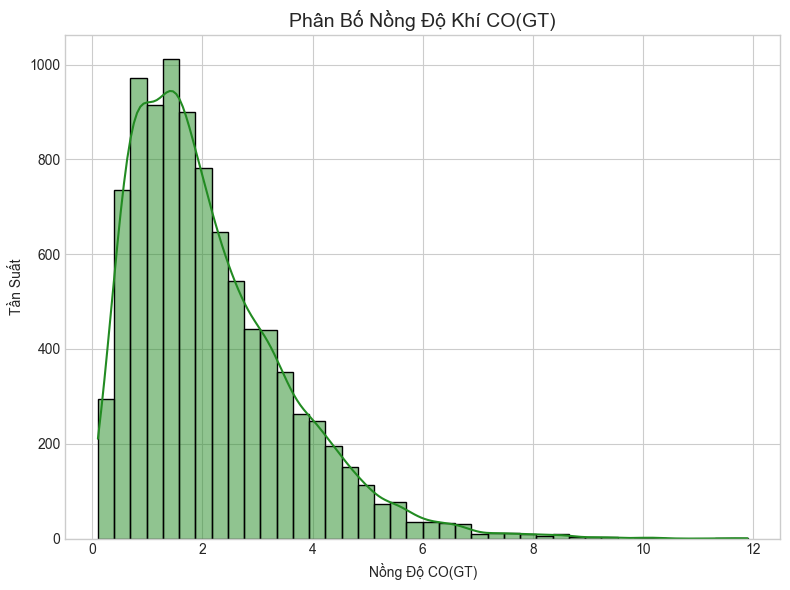

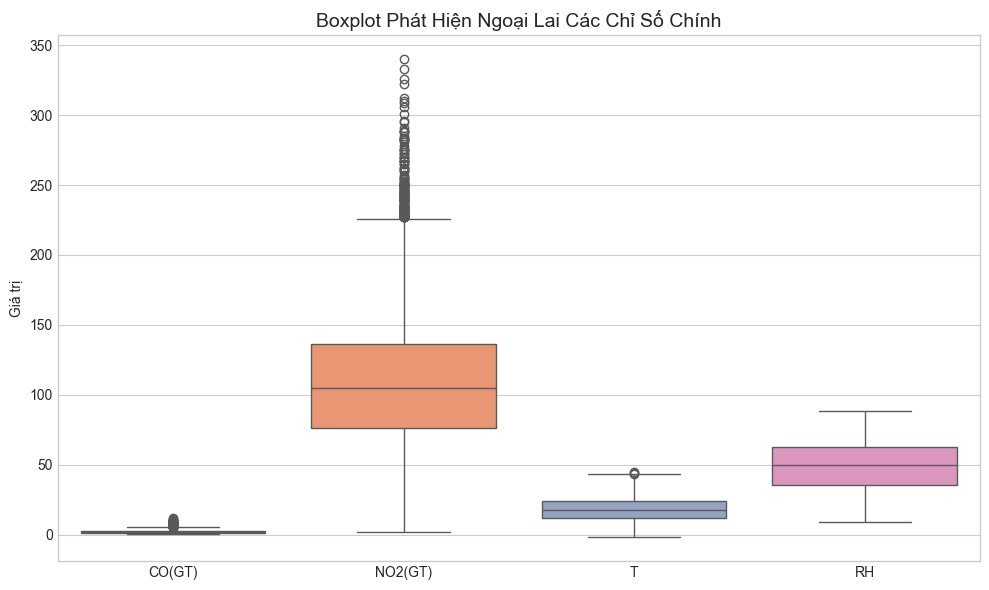

In [10]:
# 3.1. Line chart: Xu hướng nhiệt độ theo thời gian
# Resample theo tuần (W) để đường đồ thị mượt mà hơn
plt.figure(figsize=(14, 6))
df['T'].resample('W').mean().plot(color='crimson', linewidth=2, label='Nhiệt độ (T) - Trung bình Tuần')
plt.title('Biến Động Nhiệt Độ (T) Theo Thời Gian', fontsize=16)
plt.xlabel('Thời Gian (Năm-Tháng)', fontsize=12)
plt.ylabel('Nhiệt Độ (°C)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 3.2. Scatter plot: Mối quan hệ giữa Nhiệt độ và Độ ẩm
plt.figure(figsize=(8, 6))
sns.scatterplot(x='T', y='RH', data=df, alpha=0.3, color='steelblue')
plt.title('Mối Quan Hệ Giữa Nhiệt Độ (T) Và Độ Ẩm Tương Đối (RH)', fontsize=14)
plt.xlabel('Nhiệt Độ (°C)')
plt.ylabel('Độ Ẩm Tương Đối (RH %)')
plt.tight_layout()
plt.show()

# 3.3. Histogram: Phân bố của khí CO(GT)
plt.figure(figsize=(8, 6))
sns.histplot(df['CO(GT)'], bins=40, kde=True, color='forestgreen')
plt.title('Phân Bố Nồng Độ Khí CO(GT)', fontsize=14)
plt.xlabel('Nồng Độ CO(GT)')
plt.ylabel('Tần Suất')
plt.tight_layout()
plt.show()

# 3.4. Boxplot: Biểu diễn phân bố và ngoại lai của các biến chọn lọc
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['CO(GT)', 'NO2(GT)', 'T', 'RH']], palette='Set2')
plt.title('Boxplot Phát Hiện Ngoại Lai Các Chỉ Số Chính', fontsize=14)
plt.ylabel('Giá trị')
plt.tight_layout()
plt.show()

## 4. Phân tích và Kiểm định giả thuyết

In [11]:
# Tạo cột 'Hour' để phân tích theo giờ
df['Hour'] = df.index.hour

# Chia làm 2 nhóm: Ban ngày (06:00 - 18:00) và Ban đêm (18:00 - 06:00)
daytime_co = df[(df['Hour'] >= 6) & (df['Hour'] < 18)]['CO(GT)']
nighttime_co = df[(df['Hour'] < 6) | (df['Hour'] >= 18)]['CO(GT)']

print("\n--- Kiểm Định Giả Thuyết (T-Test) ---")
print("H0 (Giả thuyết không): Không có sự khác biệt về lượng CO(GT) trung bình giữa ban ngày và ban đêm.")
print("H1 (Giả thuyết đối): Có sự khác biệt có ý nghĩa về lượng CO(GT) trung bình giữa ban ngày và ban đêm.")

# Thực hiện Independent T-test
t_stat, p_val = stats.ttest_ind(daytime_co, nighttime_co, equal_var=False)

print(f"\nKết quả:")
print(f"- T-statistic: {t_stat:.4f}")
print(f"- P-value:     {p_val:.4e}")

if p_val < 0.05:
    print("=> Kết luận: Bác bỏ H0. Nồng độ CO(GT) ban ngày và ban đêm CÓ sự khác biệt mang ý nghĩa thống kê.")
else:
    print("=> Kết luận: Chưa đủ bằng chứng để bác bỏ H0.")


--- Kiểm Định Giả Thuyết (T-Test) ---
H0 (Giả thuyết không): Không có sự khác biệt về lượng CO(GT) trung bình giữa ban ngày và ban đêm.
H1 (Giả thuyết đối): Có sự khác biệt có ý nghĩa về lượng CO(GT) trung bình giữa ban ngày và ban đêm.

Kết quả:
- T-statistic: 7.6709
- P-value:     1.8824e-14
=> Kết luận: Bác bỏ H0. Nồng độ CO(GT) ban ngày và ban đêm CÓ sự khác biệt mang ý nghĩa thống kê.


## 5. Xây dựng Mô Hình Thuật Toán


--- Xây Dựng Mô Hình Hồi Quy Tuyến Tính (Linear Regression) ---
Kích thước tập huấn luyện: (7485, 8)
Kích thước tập kiểm tra:   (1872, 8)

Kết quả Đánh giá Mô hình:
- Mean Squared Error (MSE):  1.5270
- Mean Absolute Error (MAE): 0.8751
- R-squared (R2 Score):      0.9735


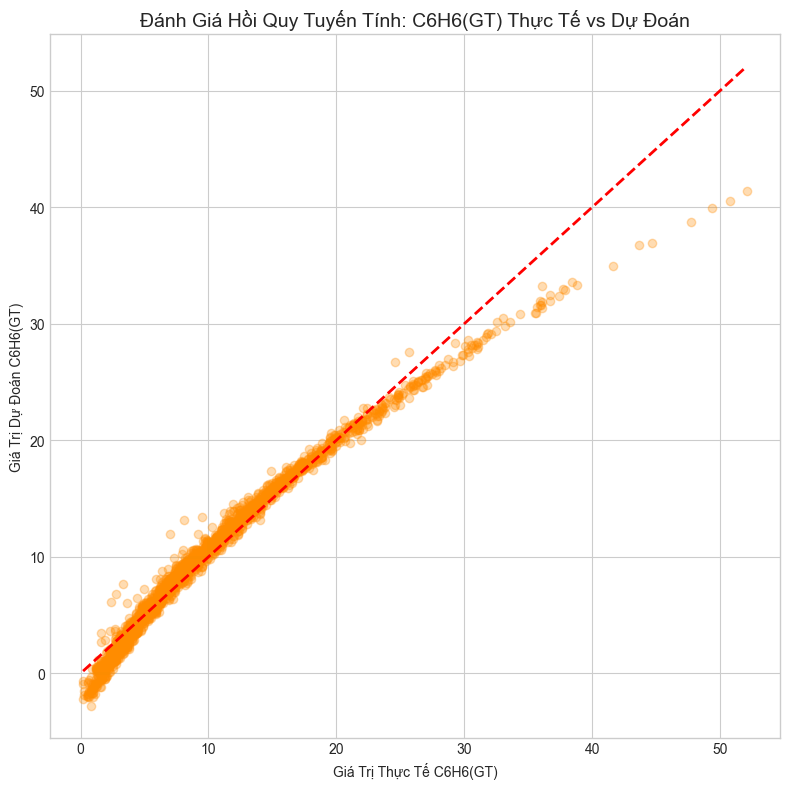


Hệ số tác động của từng đặc trưng (Coefficients):


,Biến,Hệ số
7,AH,1.888173
1,PT08.S2(NMHC),0.031564
2,PT08.S3(NOx),0.004861
0,PT08.S1(CO),0.001389
4,PT08.S5(O3),-0.000262
3,PT08.S4(NO2),-0.000938
6,RH,-0.017105
5,T,-0.099090


In [12]:
# Bài toán: Dự báo nồng độ C6H6(GT) (Benzen) dựa trên thông số các cảm biến khí khác và thời tiết.
# Đây là bài toán Hồi quy tuyến tính (Linear Regression) đơn giản nhưng hiệu quả.

features = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
target = 'C6H6(GT)'

# Loại bỏ các dòng mà target hoặc features vẫn bị rỗng (nếu có)
df_model = df.dropna(subset=[target] + features)

X = df_model[features]
y = df_model[target]

# Chia tách tập huấn luyện (Train) và tập kiểm tra (Test) theo tỉ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n--- Xây Dựng Mô Hình Hồi Quy Tuyến Tính (Linear Regression) ---")
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra:   {X_test.shape}")

# Khởi tạo và huấn luyện mô hình Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = lr_model.predict(X_test)

# Đánh giá mô hình bằng các độ đo MSE, MAE, R2-Score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nKết quả Đánh giá Mô hình:")
print(f"- Mean Squared Error (MSE):  {mse:.4f}")
print(f"- Mean Absolute Error (MAE): {mae:.4f}")
print(f"- R-squared (R2 Score):      {r2:.4f}")

# Vẽ đồ thị so sánh giá trị Thực tế và Dự đoán
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='darkorange')
# Đường chéo y = x (hoàn hảo)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Đánh Giá Hồi Quy Tuyến Tính: C6H6(GT) Thực Tế vs Dự Đoán', fontsize=14)
plt.xlabel('Giá Trị Thực Tế C6H6(GT)')
plt.ylabel('Giá Trị Dự Đoán C6H6(GT)')
plt.tight_layout()
plt.show()

# Hiển thị các hệ số (Coefficients) để xem ảnh hưởng của từng biến
coefficients = pd.DataFrame({'Biến': features, 'Hệ số': lr_model.coef_})
print("\nHệ số tác động của từng đặc trưng (Coefficients):")
display(coefficients.sort_values(by='Hệ số', ascending=False))

## 6. Kết luận

1. **Xu hướng và Dữ liệu:** 
   - Đã tiền xử lý thành công bằng nội suy để thay thế các giá trị nhiễu `-200`. 
   - Dữ liệu Nhiệt độ và CO có sự dao động mạnh và mang tính chu kỳ ngày/đêm.
2. **Kiểm định:** 
   - Chứng minh được bằng xác suất thống kê rằng nồng độ ô nhiễm ban ngày và ban đêm có sự khác biệt rõ rệt.
3. **Mô hình học máy:** 
   - Mô hình Hồi quy tuyến tính (Linear Regression) cơ bản đã cho kết quả tương đối tốt (đánh giá qua R2).
   - Điều này cho thấy các cảm biến khí (như PT08) và nhiệt độ có mối liên hệ tuyến tính tỷ lệ thuận tương đối rõ ràng với nồng độ chất Benzen (C6H6).